In [2]:
from loadmodules import *
import kepler
import figureMarkup
import specKit


def bin_density(x, y, bins=None, IDs=None, min_nopint=2, Loutlier=False):
    hh, locx, locy = np.histogram2d(x, y, bins=bins)
    z = np.array([hh[np.argmax(a<=locx[1:]),np.argmax(b<=locy[1:])] for a,b in zip(x,y)])
    idx = z.argsort()
    x2, y2, z2, IDs2 = x[idx], y[idx], z[idx], IDs[idx]
    outliers = IDs2[np.where(z2<min_nopint)[0]]
    subs = np.where(z2>=min_nopint)[0]
    x2, y2, z2 = x2[subs], y2[subs], z2[subs]
    if Loutlier: return x2, y2, z2, outliers
    if not Loutlier: return x2, y2, z2

In [3]:
###########################################################################################################
# load orbital pereriods and rotations periods for demonstrating the synchronization.
binFull = pd.read_csv("../Data/FinalCombinedData.csv")
binFull = binFull[binFull.teff.between(4000, 7000)].reset_index(drop=True)
binFull = binFull[binFull.logg>=3.5].reset_index(drop=True)
cond  = binFull.teff.between(5700, 5800) & binFull.logg.between(4.3, 4.5) & binFull.feh.between(-0.1, 0.1) & (binFull.period>32) 
MedianSolorSindex = binFull[cond].SIndex.mean()
MedianSolorSindexErr = binFull[cond].SIndexSigma.mean()/np.sqrt(len(binFull[cond]))
print(f"Number of solar analogs: {len(binFull[cond])}")
print("The median S-index of the solar-like stars: {:.3f} +/- {:.3f}".format(MedianSolorSindex, MedianSolorSindexErr))

# load the rotation star sample
sync = pd.read_csv("../Data/SynchronisationKeplerK2Sample.csv", dtype={"source_id":str})
sync = sync[sync.ref!="gaulme20"].reset_index(drop=True)
print("Number of pairs with Prot and Porb: {:d}".format(len(sync.drop(columns=["Porb", "Prot"]))))
print("Number of unique systems: {:d}".format(len(sync.drop_duplicates(subset=["starid"]))))

# calculate the synchronization rate for stars with Porb<10 days.
n_short_bin = len(sync[(sync.Porb<10)])
n_short_bin_sync = len(sync[(sync.Porb<10)&(0.5<sync.Porb/sync.Prot)&(sync.Porb/sync.Prot<2)])
print("The fraction of non-synchronised systems: {:.3f}".format(1-n_short_bin_sync/n_short_bin))

# check the fraction of stars that are approximately synchronous when Porb<32.
syncRatio = len(sync[(sync.Porb<32)&((0.5<=sync.Porb/sync.Prot)&(sync.Porb/sync.Prot<2))]) / len(sync[(sync.Porb<32)]) 
print("The fraction of approximately synchronous systems when Porb<32: {:.3f}".format(syncRatio))
syncRatio = len(sync[(sync.Porb>32)&((0.5<=sync.Porb/sync.Prot)&(sync.Porb/sync.Prot<2))]) / len(sync[(sync.Porb>32)]) 
print("The fraction of approximately synchronous systems when Porb>32: {:.3f}".format(syncRatio))

# check the eccentricities of the non-synchronous stars.
asyncstars = sync[(sync.Porb<10)&((0.5>sync.Porb/sync.Prot)|(sync.Porb/sync.Prot>=2))]
asyncstars = pd.merge(asyncstars, binFull[["source_id", "eccentricity"]], on="source_id")
asyncstars = asyncstars.drop_duplicates(subset=["source_id"]).reset_index(drop=True)
print("Eccentricities of stars that are not synchronous: ")
asyncstars

Number of solar analogs: 135
The median S-index of the solar-like stars: 0.196 +/- 0.005
Number of pairs with Prot and Porb: 1409
Number of unique systems: 1348
The fraction of non-synchronised systems: 0.108
The fraction of approximately synchronous systems when Porb<32: 0.868
The fraction of approximately synchronous systems when Porb>32: 0.026
Eccentricities of stars that are not synchronous: 


,starid,Prot,ref,source,source_id,Porb,eccentricity_x,semi_amplitude_primary,massfunc,eccentricity_y
0,KIC3340951,9.23,santos21,kepler,Gaia DR3 2052649296940185344,0.599211,0.091349,7.466734,0.000026,0.091349
1,KIC6185841,6.84,santos21,kepler,Gaia DR3 2104098160418655488,1.827416,0.182231,17.287676,0.000930,0.182231
2,KIC6609876,20.02,santos21,kepler,Gaia DR3 2077690365021037568,1.672397,0.073992,6.887945,0.000056,0.073992
3,KIC7676439,20.06,santos21,kepler,Gaia DR3 2102816301661180928,6.690457,0.336749,3.622333,0.000028,0.336749
4,KIC9051076,1.64,santos21,kepler,Gaia DR3 2085177691313762432,0.718161,0.217590,12.213855,0.000126,0.217590
5,KIC9598315,19.37,santos21,kepler,Gaia DR3 2080408392127397632,0.554103,0.119414,14.592255,0.000175,0.119414
6,KIC10859792,1.79,santos21,kepler,Gaia DR3 2129315764542613632,0.612863,0.173792,15.887562,0.000243,0.173792
7,EPIC212134948,28.03,reinhold20,k2,Gaia DR3 665923855928018048,1.811735,0.064442,7.748104,0.000087,0.064442


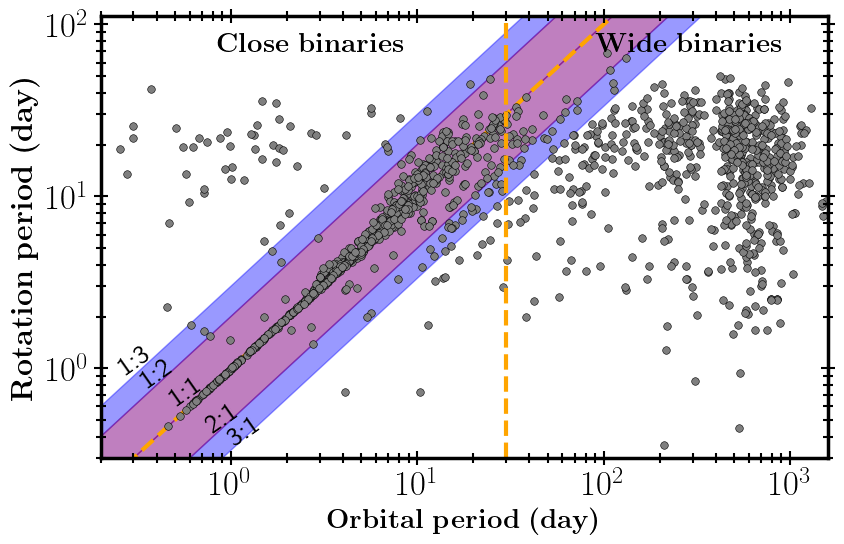

In [12]:

################################################################################################
# Without background colors indicating the level of synchronisation.
fig, ax = plt.subplots(1,1, figsize=(9,6))
ax.axvline(30, ls="--", color="orange", lw=3)
ax.fill_between(np.linspace(0.1, 4000, 10), np.linspace(0.1/2, 4000/2, 10), y2=np.linspace(0.1/3, 4000/3, 10), color="blue", alpha=0.4)
ax.fill_between(np.linspace(0.1, 4000, 10), np.linspace(0.1, 4000, 10), y2=np.linspace(0.1/2, 4000/2, 10), color="purple", alpha=0.5)
ax.fill_between(np.linspace(0.1, 4000, 10), np.linspace(0.1*2, 4000*2, 10), y2=np.linspace(0.1*3, 4000*3, 10), color="blue", alpha=0.4)
ax.fill_between(np.linspace(0.1, 4000, 10), np.linspace(0.1, 4000, 10), y2=np.linspace(0.1*2, 4000*2, 10), color="purple", alpha=0.5)
ax.plot(np.linspace(0.1, 4000, 10), np.linspace(0.1, 4000, 10), ls="--", color="orange", lw=3, zorder=1)
ax.scatter(sync.Porb, sync.Prot, fc="tab:grey", ec="k", lw=0.4, s=30)
kepler.figure_annotation(ax, coords=[0.16, 0.92], text=[r"$\boldsymbol{\rm Close~binaries}$"], color="k")
kepler.figure_annotation(ax, coords=[0.68, 0.92], text=[r"$\boldsymbol{\rm Wide~binaries}$"], color="k")
kepler.figure_annotation(ax, coords=[0.09, 0.12], coords_type="axes fraction", text=["1:1"], color="k", fontsize=20, rotation=35)
kepler.figure_annotation(ax, coords=[0.05, 0.16], coords_type="axes fraction", text=["1:2"], color="k", fontsize=20, rotation=35)
kepler.figure_annotation(ax, coords=[0.02, 0.19], coords_type="axes fraction", text=["1:3"], color="k", fontsize=20, rotation=35)
kepler.figure_annotation(ax, coords=[0.14, 0.06], coords_type="axes fraction", text=["2:1"], color="k", fontsize=20, rotation=35)
kepler.figure_annotation(ax, coords=[0.17, 0.03], coords_type="axes fraction", text=["3:1"], color="k", fontsize=20, rotation=35)
ax.set_ylim(0.3, 112)
ax.set_xlim(0.2, 1600)  
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$", fontsize=20)
ax.set_ylabel(r"$\boldsymbol{\rm Rotation~period~(day)}$", fontsize=22)
plt.tight_layout()
plt.savefig("../Figures/RotationOrbiralPeriodsNoBgLinearScale.pdf", bbox_inches='tight')
plt.savefig("../Figures/RotationOrbiralPeriodsNoBgLinearScale.jpg", dpi=350, facecolor='w', bbox_inches='tight')

plt.show()

The median S Index uncertainty is 0.008 of the entire sample
The median S Index uncertainty is 0.008 of the entire sample


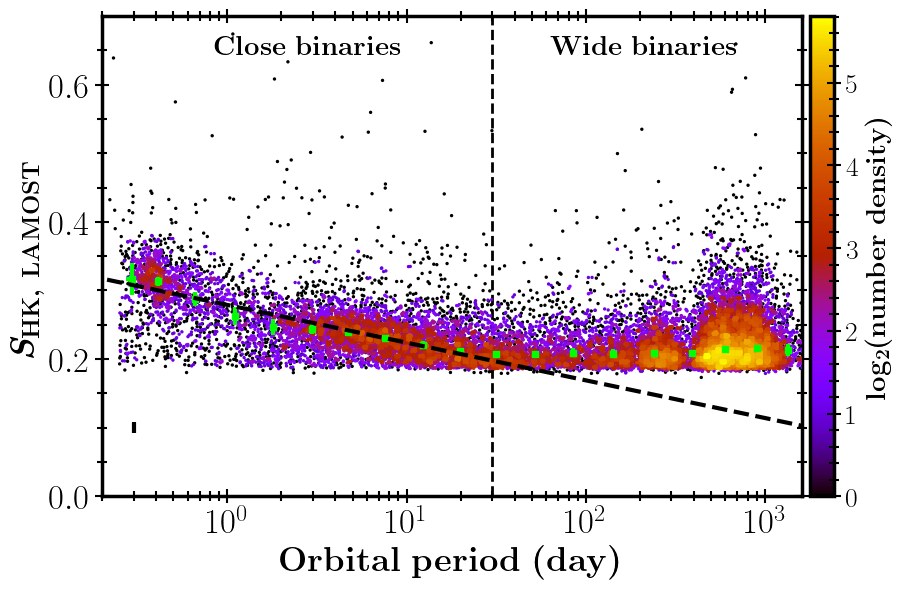

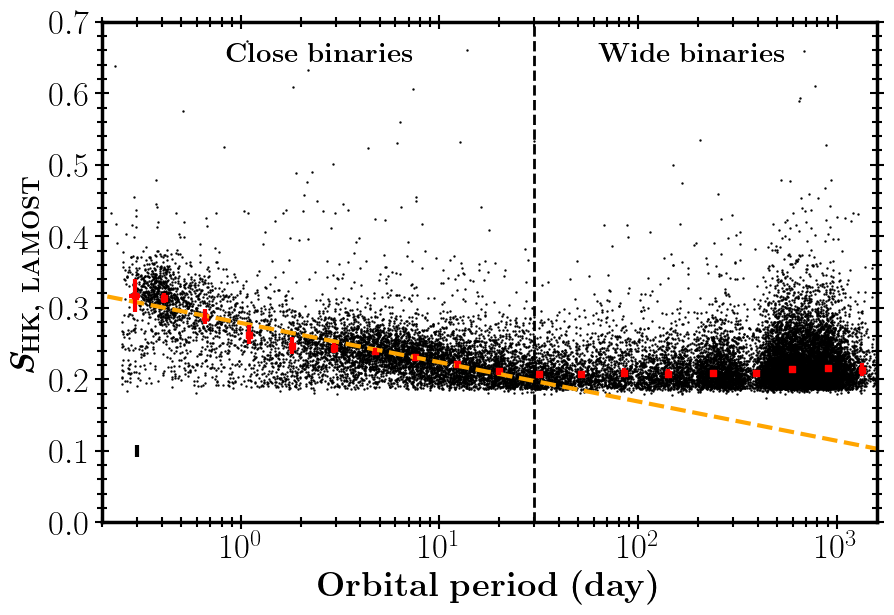

In [15]:
# With a background color map
# calculate the median values in bins.
binFull = binFull[binFull.logg.notnull() & binFull.period.notnull()].reset_index(drop=True) # remove Kepler/K2 rotators.
stat = kepler.bin(x=np.log10(binFull[binFull.logg>=3.5].period.values), y=binFull[binFull.logg>=3.5].SIndexOri.values, bins=np.linspace(-0.7, 3.3, 20), suffixes=["P", "S"], LdivideN=True)
stat = stat.apply(pd.to_numeric)
stat_fit = stat[(-2<stat.median_P)&(stat.median_P<1.5)]
alpha, alphaerr, beta, betaerr = kepler.do_line_fit(stat_fit.median_P.values, stat_fit.median_S.values, stat_fit.std_S.values)
x = np.linspace(-10, 10)
y = alpha*x+beta
# calculate number density
bins = [np.arange(-0.7, 3.5, 0.01), np.arange(-0.2, 1.0, 0.01)]
bins = [200, 150]
A = np.log10(binFull[binFull.logg>=3.5].period.values)
B = binFull[binFull.logg>=3.5].SIndexOri.values
IDs = binFull[binFull.logg>=3.5].source_id.values
x2, y2, z2 = bin_density(A, B, bins=bins, IDs=IDs, min_nopint=1, Loutlier=False)
# show SIndexOri vs period 
fig, ax = plt.subplots(1,1, figsize=(10,6.5))
cb=ax.scatter(10**x2, y2, c=np.log2(z2), cmap="gnuplot", s=2, zorder=11)
ax.plot(10**x, y, zorder=14, lw=3, c='k', ls="--")
cbar = plt.colorbar(cb, orientation="vertical", pad=0.01)
cbar.ax.tick_params(which='major', labelsize=20)     
cbar.set_label(r"$\boldsymbol{\rm{log_{2}}(number~density)}$", fontsize=20)
cbar.ax.xaxis.set_ticks_position('top')
ax.errorbar(10**stat.median_P, stat.median_S, xerr=stat.std_P/10**stat.median_P/np.log(10)*5, yerr=stat.std_S*5, c="lime", zorder=12, ls="None", ms=15, lw=3)
# ax.errorbar([1300], [0.5], yerr=binFull[binFull.logg>=3.5].SIndexOriSigma.median(), c="k", marker="s", zorder=12, ms=5, lw=2)
ax.errorbar([0.3], [0.1], yerr=binFull[binFull.logg>=3.5].SIndexOriSigma.median(), c="k", marker="none", zorder=12, lw=3)
print("The median S Index uncertainty is {:.3f} of the entire sample".format(binFull.SIndexOriSigma.median()))
ax.scatter(10**stat.median_P, stat.median_S, s=20, marker="s", zorder=13, c="lime")
ax.axvline(30, ls="--", color="k", lw=2)
ax.set_ylim(0, 0.7)
ax.set_xlim(0.2, 1600)
ax.set_xscale("log")
# ################################################################################################
kepler.figure_annotation(ax, coords=[0.16, 0.92], text=[r"$\boldsymbol{\rm Close~binaries}$"], color="k")
kepler.figure_annotation(ax, coords=[0.64, 0.92], text=[r"$\boldsymbol{\rm Wide~binaries}$"], color="k")
ax.set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
ax.set_ylabel(r"$\boldsymbol{\it{S}_{\rm HK,~LAMOST}}$")
plt.tight_layout()
# plt.savefig("../Figures/PeriodSIndexOriDwarfsNobgLinearScale.png", dpi=300, facecolor='w', bbox_inches='tight')


# ################################################################################################
# (4) Without a background color map or color bar
fig, ax = plt.subplots(1,1, figsize=(10, 6.5))
ax.scatter(10**x2, y2, s=.5, c="k")
# ax.scatter(10**x2, y2, s=20, ec="k", lw=0.6, fc="grey", alpha=0.3)
ax.plot(10**x, y, lw=3, c='orange', ls="--")
ax.errorbar(10**stat.median_P, stat.median_S, xerr=stat.std_P/10**stat.median_P/np.log(10)*5, yerr=stat.std_S*5, c="r", ls="None", ms=25, lw=3)
ax.errorbar([0.3], [0.1], yerr=binFull[binFull.logg>=3.5].SIndexOriSigma.median(), c="k", marker="none", lw=3)
print("The median S Index uncertainty is {:.3f} of the entire sample".format(binFull.SIndexOriSigma.median()))
ax.scatter(10**stat.median_P, stat.median_S, s=20, marker="s", c="r")
ax.axvline(30, ls="--", color="k", lw=2)
ax.set_ylim(0, 0.7)
ax.set_xlim(0.2, 1600)
ax.set_xscale("log")
kepler.figure_annotation(ax, coords=[0.16, 0.92], text=[r"$\boldsymbol{\rm Close~binaries}$"], color="k")
kepler.figure_annotation(ax, coords=[0.64, 0.92], text=[r"$\boldsymbol{\rm Wide~binaries}$"], color="k")
ax.set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
ax.set_ylabel(r"$\boldsymbol{\it{S}_{\rm HK,~LAMOST}}$")
plt.savefig("../Figures/PeriodSIndexOriDwarfsNobgLinearScale.jpg", dpi=300, facecolor='w', bbox_inches='tight')
plt.savefig("../Figures/PeriodSIndexOriDwarfsNobgLinearScale.pdf", bbox_inches='tight')

The median S Index uncertainty is 0.009 of the entire sample
number of stars shown in the figure: 2079
The median S Index uncertainty is 0.009 of the entire sample
number of stars shown in the figure: 2079


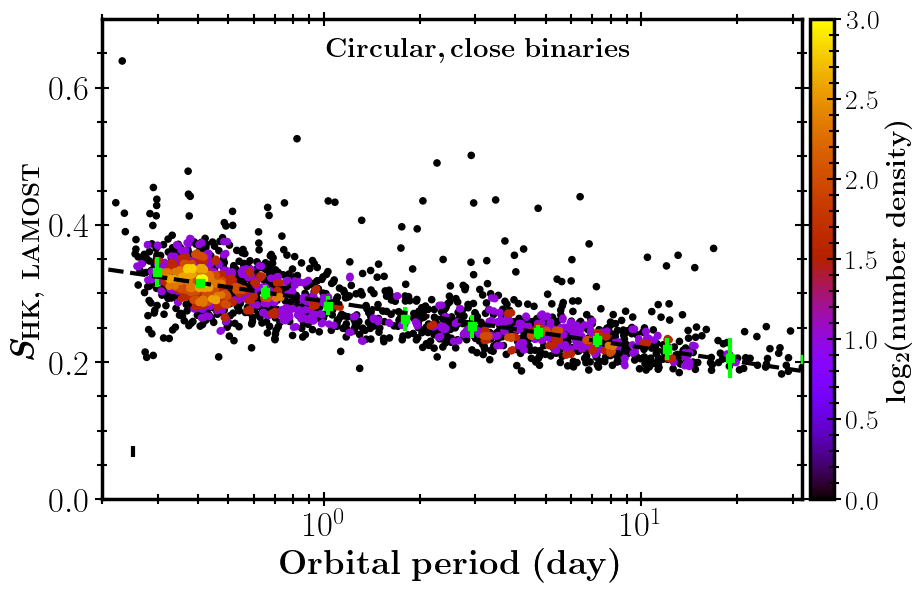

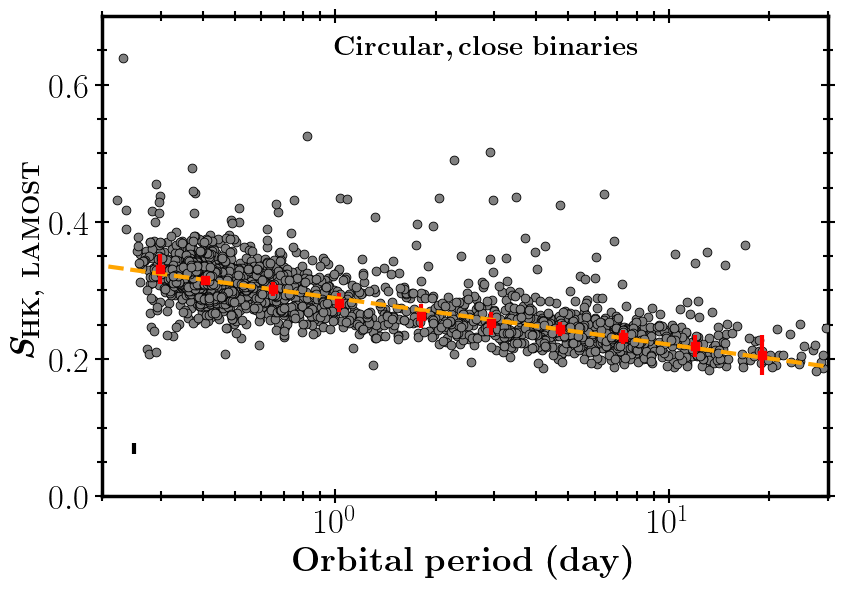

In [17]:
################################################################################################
# Without a background color map
# calculate the median values in bins.
binFullSub = binFull[binFull.logg.notnull() & binFull.period.notnull() & (binFull.eccentricity<0.03)].reset_index(drop=True) # remove Kepler/K2 rotators.
stat = kepler.bin(x=np.log10(binFullSub[binFullSub.logg>=3.5].period.values), y=binFullSub[binFullSub.logg>=3.5].SIndexOri.values, bins=np.linspace(-0.7, 3.3, 20), suffixes=["P", "S"], LdivideN=True)
stat = stat.apply(pd.to_numeric)
stat_fit = stat[(-2<stat.median_P)&(stat.median_P<1.5)]
alpha, alphaerr, beta, betaerr = kepler.do_line_fit(stat_fit.median_P.values, stat_fit.median_S.values, stat_fit.std_S.values)
x = np.linspace(-10, 10)
y = alpha*x+beta
# calculate number density
bins = [np.arange(-0.7, 3.5, 0.01), np.arange(-0.2, 1.0, 0.01)]
bins = [200, 150]
A = np.log10(binFullSub[binFullSub.logg>=3.5].period.values)
B = binFullSub[binFullSub.logg>=3.5].SIndexOri.values
IDs = binFullSub[binFullSub.logg>=3.5].source_id.values
x2, y2, z2 = bin_density(A, B, bins=bins, IDs=IDs, min_nopint=1, Loutlier=False)
# show SIndexOri vs period 
fig, ax = plt.subplots(1,1, figsize=(10,6.5))
cb=ax.scatter(10**x2, y2, c=np.log2(z2), cmap="gnuplot", s=20, zorder=11)
ax.plot(10**x, y, zorder=14, lw=3, c='k', ls="--")
# cax = fig.add_axes([0.62, 0.70, 0.3, 0.04])
cbar = plt.colorbar(cb, orientation="vertical", pad=0.01)
cbar.ax.tick_params(which='major', labelsize=20)     
cbar.set_label(r"$\boldsymbol{\rm{log_{2}}(number~density)}$", fontsize=20)
cbar.ax.xaxis.set_ticks_position('top')
ax.scatter(10**stat.median_P, stat.median_S, s=40, marker="s", zorder=16, c="lime")
ax.errorbar(10**stat.median_P, stat.median_S, xerr=stat.std_P/10**stat.median_P/np.log(10), yerr=stat.std_S*5, c="lime", zorder=12, ls="None", ms=15, lw=3)
# ax.errorbar([25], [0.5], yerr=binFullSub[binFullSub.logg>=3.5].SIndexOriSigma.median(), c="k", marker="s", zorder=12, ms=5, lw=2)
ax.errorbar([0.25], [0.07], yerr=binFull[binFull.logg>=3.5].SIndexOriSigma.median(), c="k", marker="none", zorder=12, lw=3)
print("The median S Index uncertainty is {:.3f} of the entire sample".format(binFullSub.SIndexOriSigma.median()))
ax.set_ylim(0, 0.7)
ax.set_xlim(0.2, 32)
kepler.figure_annotation(ax, coords=[0.32, 0.92], text=[r"$\boldsymbol{\rm Circular,close~binaries}$"], color="k")
ax.set_xscale("log")
ax.set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
ax.set_ylabel(r"$\boldsymbol{\it{S}_{\rm HK,~LAMOST}}$")
plt.tight_layout()
nstars = len(np.where((0.2<10**x2) & (10**x2<32))[0])
print(f"number of stars shown in the figure: {nstars}")
# plt.savefig("../Figures/PeriodSIndexOriDwarfsNoBgCircularLinearScale.png", dpi=300, facecolor='w', bbox_inches='tight')


# show SIndexOri vs period 
fig, ax = plt.subplots(1,1, figsize=(9,6.5))
cb=ax.scatter(10**x2, y2,  s=40, zorder=11, ec="k", lw=0.6, fc="grey") #ADD8E6
ax.plot(10**x, y, zorder=14, lw=3, c='orange', ls="--")
ax.scatter(10**stat.median_P, stat.median_S, s=40, marker="s", zorder=16, c="r")
ax.errorbar(10**stat.median_P, stat.median_S, xerr=stat.std_P/10**stat.median_P/np.log(10), yerr=stat.std_S*5, c="r", zorder=12, ls="None", ms=15, lw=3)
ax.errorbar([0.25], [0.07], yerr=binFull[binFull.logg>=3.5].SIndexOriSigma.median(), c="k", marker="none", zorder=12, lw=3)
print("The median S Index uncertainty is {:.3f} of the entire sample".format(binFullSub.SIndexOriSigma.median()))
ax.set_ylim(0, 0.7)
ax.set_xlim(0.2, 30)
kepler.figure_annotation(ax, coords=[0.32, 0.92], text=[r"$\boldsymbol{\rm Circular,close~binaries}$"], color="k")
ax.set_xscale("log")
ax.set_xlabel(r"$\boldsymbol{\rm Orbital~period~(day)}$")
ax.set_ylabel(r"$\boldsymbol{\it{S}_{\rm HK,~LAMOST}}$")
plt.tight_layout()
plt.savefig("../Figures/PeriodSIndexOriDwarfsNoBgCircularLinearScale.jpg", dpi=300, facecolor='w', bbox_inches='tight')
plt.savefig("../Figures/PeriodSIndexOriDwarfsNoBgCircularLinearScale.pdf", bbox_inches='tight')

nstars = len(np.where((0.2<10**x2) & (10**x2<30))[0])
print(f"number of stars shown in the figure: {nstars}")